<a href="https://colab.research.google.com/github/edusatyaki/SummerDrive/blob/main/Cohort-1/NYC%20Taxi/Data%20Analysis/NYC_Taxi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Step 1: PySpark Setup**

Installing the PySpark library (not available by default in Colab) and creating a SparkSession — this is the main entry point through which we perform all data operations.

The dataset is very large (12 months, 400+ million rows), so regular pandas won't work at this scale — Spark uses distributed/parallel processing, which allows it to handle large data efficiently.

master("local[*]") — use all available CPU cores in Colab. spark.driver.memory = 8g — allocate 8GB RAM to Spark for processing. spark.sql.session.timeZone — interpret timestamps in NYC's time zone (America/New_York) so hour/day calculations are accurate.

In [1]:
!pip install -q pyspark

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql.types import *

spark = (
    SparkSession.builder
    .appName("nyc-yellow-taxi-2025-analysis")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .config("spark.driver.memory", "8g")
    .config("spark.sql.session.timeZone", "America/New_York")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")
print("Spark version:", spark.version)

Spark version: 4.0.3


**Step 2: Mounting Google Drive**

Connecting (mounting) Google Drive to the Colab environment so that files stored in Drive (the cleaned data shared by the teammate) can be accessed from here.

The cleaned dataset is stored on Drive, not on the local Colab disk — once mounted, files can be read from the /content/drive/MyDrive/... path.

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


**Step 3: Locating the 12 Monthly CSV Files**

Using the glob module to find all 12 monthly cleaned CSV (gzip-compressed) files in the shared Drive folder, and verifying that all 12 are present.

The teammate provided the cleaned data as 12 separate files (NYC_Taxi_Cleaned_2025_01.csv.gz through _12.csv.gz) in one folder — so we need to locate all of them before loading. The assert statement is a safety check that stops the notebook if any file is missing.

In [3]:
import glob

monthly_files = sorted(glob.glob(
    "/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_*.csv.gz"
))

print("Files found:", len(monthly_files))
for f in monthly_files:
    print(f)

assert len(monthly_files) == 12, "Expected 12 monthly CSV files."

Files found: 12
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_01.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_02.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_03.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_04.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_05.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_06.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_07.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_08.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_09.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_10.csv.gz
/content/drive/MyDrive/Colab Notebooks/Cleaned Dataset/NYC_Taxi_Cleaned_2025_11.csv.gz
/content/drive/MyDrive/Cola

**Step 4: Copying Files from Drive to Local Colab Disk**

This step copies all 12 files from Google Drive to Colab's local storage directory (/content/csv_data).

Google Drive is a network-mounted storage system, resulting in slower read/write performance compared to local disk. By copying the files once and performing all subsequent processing on the local copies, overall execution speed is significantly improved.

In [4]:
import shutil, os

local_csv_dir = "/content/csv_data"
os.makedirs(local_csv_dir, exist_ok=True)

local_files = []
for f in monthly_files:
    dest = os.path.join(local_csv_dir, os.path.basename(f))
    if not os.path.exists(dest):
        shutil.copy(f, dest)
    local_files.append(dest)

print("Copied", len(local_files), "files locally to", local_csv_dir)

Copied 12 files locally to /content/csv_data


**Step 5: Inferring Schema**

This step automatically infers data types (schema) from the first file and reuses this schema for the remaining 11 files.


Applying inferSchema=True across all 12 files simultaneously would require Spark to perform an additional full scan of the dataset solely to determine data types, which is computationally expensive. Since schema consistency across all files was already verified during the cleaning stage, extracting the schema once and reusing it reduces processing time.

In [5]:
sample_df = spark.read.csv(local_files[0], header=True, inferSchema=True)
csv_schema = sample_df.schema

print("Schema inferred from:", local_files[0])
sample_df.printSchema()

Schema inferred from: /content/csv_data/NYC_Taxi_Cleaned_2025_01.csv.gz
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-- DOLocationID: integer (nullable = true)
 |-- payment_type: integer (nullable = true)
 |-- fare_amount: double (nullable = true)
 |-- extra: double (nullable = true)
 |-- mta_tax: double (nullable = true)
 |-- tip_amount: double (nullable = true)
 |-- tolls_amount: double (nullable = true)
 |-- improvement_surcharge: double (nullable = true)
 |-- total_amount: double (nullable = true)
 |-- congestion_surcharge: double (nullable = true)
 |-- Airport_fee: double (nullable = true)
 |-- cbd_congestion_fee: double (nullable = true)
 |-

**Step 6: Individual Monthly Conversion to Parquet Format**

This step reads each monthly CSV file sequentially within a loop and converts each to Parquet format using the previously inferred schema, saving the output to local disk.

(1) CSV versus Parquet — CSV files, particularly gzip-compressed ones, cannot be read in parallel by Spark due to their non-splittable nature. Parquet is a columnar, compressed format optimized for both read and write performance in Spark.

(2) Sequential monthly processing — attempting to load the entire dataset (400+ million rows) into memory simultaneously risks exceeding Colab's limited free-tier RAM. Processing each month independently maintains manageable memory usage.

(3) repartition

(4) distributes the data into four partitions to enable parallel write operations across multiple cores.

This conversion represents a one-time computational cost; all subsequent analysis is performed on the resulting Parquet format for improved efficiency.

In [6]:
local_parquet_dir = "/content/parquet_data"

for f in local_files:
    month_name = os.path.basename(f).replace(".csv.gz", "")
    month_df = spark.read.csv(f, header=True, schema=csv_schema)
    month_df = month_df.repartition(4)
    (
        month_df.write
        .mode("overwrite")
        .parquet(f"{local_parquet_dir}/{month_name}")
    )
    print("Converted:", month_name)

print("All months converted to parquet.")

Converted: NYC_Taxi_Cleaned_2025_01
Converted: NYC_Taxi_Cleaned_2025_02
Converted: NYC_Taxi_Cleaned_2025_03
Converted: NYC_Taxi_Cleaned_2025_04
Converted: NYC_Taxi_Cleaned_2025_05
Converted: NYC_Taxi_Cleaned_2025_06
Converted: NYC_Taxi_Cleaned_2025_07
Converted: NYC_Taxi_Cleaned_2025_08
Converted: NYC_Taxi_Cleaned_2025_09
Converted: NYC_Taxi_Cleaned_2025_10
Converted: NYC_Taxi_Cleaned_2025_11
Converted: NYC_Taxi_Cleaned_2025_12
All months converted to parquet.


**Step 7: Backing Up Converted Parquet Data to Google Drive**

This step permanently copies the local /content/parquet_data directory, which would otherwise be deleted upon runtime disconnection, to Google Drive.


Colab's local storage (/content/) is temporary and is cleared whenever the runtime disconnects or restarts. Backing up the converted data to Drive ensures that future sessions can load the Parquet files directly, without repeating the CSV-to-Parquet conversion process.

In [7]:
backup_path = "/content/drive/MyDrive/NYC_Taxi_Parquet_Backup"
shutil.copytree(local_parquet_dir, backup_path, dirs_exist_ok=True)
print("Backed up to:", backup_path)

Backed up to: /content/drive/MyDrive/NYC_Taxi_Parquet_Backup


In [11]:
import os

for root, dirs, files in os.walk(local_parquet_dir):
    print(root, "->", files[:5], "..." if len(files) > 5 else "")

/content/parquet_data -> [] 
/content/parquet_data/NYC_Taxi_Cleaned_2025_09 -> ['part-00000-8fb9adda-6e9d-4c10-a2aa-71b119aa23e9-c000.snappy.parquet', 'part-00001-8fb9adda-6e9d-4c10-a2aa-71b119aa23e9-c000.snappy.parquet', '.part-00001-8fb9adda-6e9d-4c10-a2aa-71b119aa23e9-c000.snappy.parquet.crc', 'part-00002-8fb9adda-6e9d-4c10-a2aa-71b119aa23e9-c000.snappy.parquet', '.part-00003-8fb9adda-6e9d-4c10-a2aa-71b119aa23e9-c000.snappy.parquet.crc'] ...
/content/parquet_data/NYC_Taxi_Cleaned_2025_03 -> ['part-00000-603bff19-b2f5-4168-a9e9-18252b8bdb12-c000.snappy.parquet', 'part-00001-603bff19-b2f5-4168-a9e9-18252b8bdb12-c000.snappy.parquet', '_SUCCESS', 'part-00003-603bff19-b2f5-4168-a9e9-18252b8bdb12-c000.snappy.parquet', '.part-00000-603bff19-b2f5-4168-a9e9-18252b8bdb12-c000.snappy.parquet.crc'] ...
/content/parquet_data/NYC_Taxi_Cleaned_2025_12 -> ['part-00002-b165fad3-ea4d-47f8-baa6-17d12d5c067d-c000.snappy.parquet', '.part-00002-b165fad3-ea4d-47f8-baa6-17d12d5c067d-c000.snappy.parquet.crc

**Step 8: Correct Method for Loading Combined Parquet Data**

This step uses glob to compile the exact paths of all 12 monthly folders into a list, then uses spark.read.parquet(*parquet_paths) to explicitly combine them into a single DataFrame — resulting in successful execution.

Providing explicit paths prevents Spark from attempting to infer partitioning from the folder structure, instead performing a direct union of the datasets. The .cache() call stores this combined dataset in memory, improving the performance of all subsequent analytical queries.

In [12]:
import glob, os

parquet_paths = sorted([
    p for p in glob.glob(f"{local_parquet_dir}/*")
    if os.path.isdir(p)
])

print("Folders found:", len(parquet_paths))
for p in parquet_paths:
    print(p)

clean = spark.read.parquet(*parquet_paths)
clean.cache()

print("Rows:", clean.count())
print("Columns:", len(clean.columns))
clean.printSchema()

Folders found: 12
/content/parquet_data/NYC_Taxi_Cleaned_2025_01
/content/parquet_data/NYC_Taxi_Cleaned_2025_02
/content/parquet_data/NYC_Taxi_Cleaned_2025_03
/content/parquet_data/NYC_Taxi_Cleaned_2025_04
/content/parquet_data/NYC_Taxi_Cleaned_2025_05
/content/parquet_data/NYC_Taxi_Cleaned_2025_06
/content/parquet_data/NYC_Taxi_Cleaned_2025_07
/content/parquet_data/NYC_Taxi_Cleaned_2025_08
/content/parquet_data/NYC_Taxi_Cleaned_2025_09
/content/parquet_data/NYC_Taxi_Cleaned_2025_10
/content/parquet_data/NYC_Taxi_Cleaned_2025_11
/content/parquet_data/NYC_Taxi_Cleaned_2025_12
Rows: 43902255
Columns: 27
root
 |-- VendorID: integer (nullable = true)
 |-- tpep_pickup_datetime: timestamp (nullable = true)
 |-- tpep_dropoff_datetime: timestamp (nullable = true)
 |-- passenger_count: integer (nullable = true)
 |-- trip_distance: double (nullable = true)
 |-- RatecodeID: integer (nullable = true)
 |-- store_and_fwd_flag: string (nullable = true)
 |-- PULocationID: integer (nullable = true)
 |-

**Step 9: Importing Visualization Libraries**

This step imports matplotlib and seaborn for chart and graph generation, and initializes an empty analysis_logs list to record a summary of each analytical step for documentation purposes.

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

analysis_logs = []

**Step 10: Monthly Trip Volume and Revenue Seasonality**

This step groups the data by month to calculate total trip counts and total revenue, then constructs a dual-axis chart (bar chart for trip count, line chart for revenue) to enable direct comparison of the two metrics.

Business insight: This analysis reveals how demand and revenue fluctuated across months, allowing identification of seasonal patterns such as periods of elevated demand or notable declines.

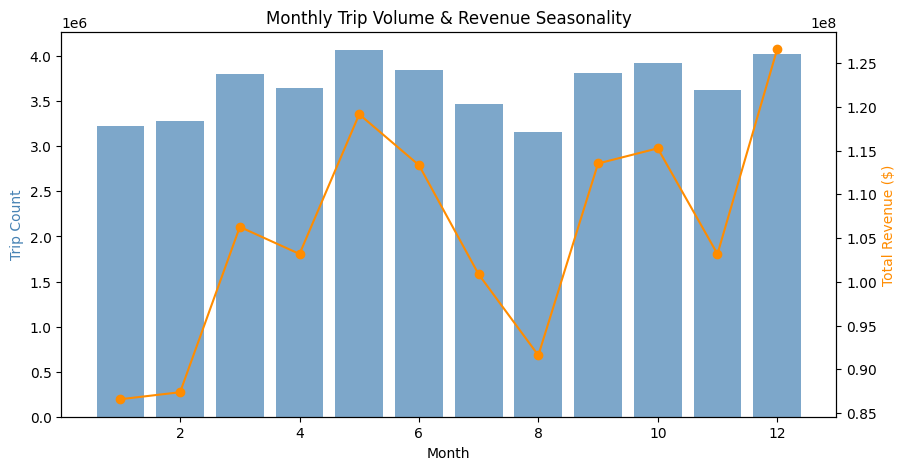

In [15]:
monthly_summary = clean.groupBy("pickup_month").agg(
    F.count("*").alias("trip_count"),
    F.sum("total_amount").alias("total_revenue")
).orderBy("pickup_month")

pdf_monthly = monthly_summary.toPandas()

fig, ax1 = plt.subplots(figsize=(10,5))
ax1.bar(pdf_monthly["pickup_month"], pdf_monthly["trip_count"], color="steelblue", alpha=0.7)
ax1.set_xlabel("Month"); ax1.set_ylabel("Trip Count", color="steelblue")

ax2 = ax1.twinx()
ax2.plot(pdf_monthly["pickup_month"], pdf_monthly["total_revenue"], color="darkorange", marker="o")
ax2.set_ylabel("Total Revenue ($)", color="darkorange")

plt.title("Monthly Trip Volume & Revenue Seasonality")
plt.show()

analysis_logs.append(("Step 1", "Plotted monthly trip volume and revenue to identify seasonality trends."))

**Step 11: Hourly Demand Heatmap (Weekday versus Weekend)**

This step classifies each trip as "Weekday" or "Weekend" based on the day_of_week field, then visualizes hour-wise trip counts as a heatmap, with hour of day on the x-axis and weekday/weekend classification on the y-axis.

Business insight: This visualization clearly identifies peak demand periods and illustrates how demand patterns differ between weekdays and weekends — for example, weekday commute-hour peaks versus weekend late-night peaks.


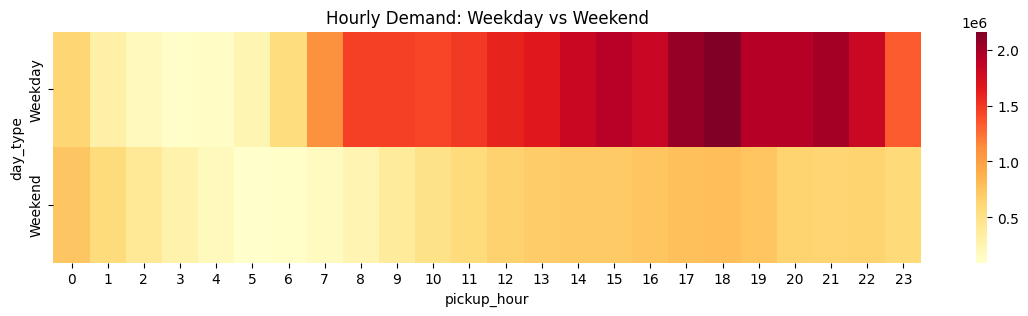

In [16]:
demand_df = clean.withColumn(
    "day_type", F.when(F.col("day_of_week").isin([1, 7]), "Weekend").otherwise("Weekday")
)

hourly_demand = demand_df.groupBy("pickup_hour", "day_type").count()
pdf_hourly = hourly_demand.toPandas()
pivot = pdf_hourly.pivot(index="day_type", columns="pickup_hour", values="count")

plt.figure(figsize=(14,3))
sns.heatmap(pivot, cmap="YlOrRd")
plt.title("Hourly Demand: Weekday vs Weekend")
plt.show()

analysis_logs.append(("Step 2", "Built hourly demand heatmap comparing weekday vs weekend patterns."))

**Step 12: Fare Distribution and Airport versus Standard Trip Economics**

This step categorizes trips as "Airport" (JFK/Newark) or "Standard" based on RatecodeID, then compares average fare, distance, and duration between the two categories. A distribution histogram of fare_amount is also generated using a 1% random sample to avoid processing the entire dataset.

Business insight: Airport trips typically generate higher fares than standard trips, which is useful for identifying high-value trip segments.

+---------+-----------------+------------------+------------------+------------------+----------+
|trip_type|avg_fare         |avg_total         |avg_distance      |avg_duration      |trip_count|
+---------+-----------------+------------------+------------------+------------------+----------+
|Airport  |70.83170116381213|95.3096605529657  |17.400147265399873|50.952658696796874|1326245   |
|Standard |18.45570082001468|26.789523569973678|3.0605951015598154|16.177124639752403|42576010  |
+---------+-----------------+------------------+------------------+------------------+----------+



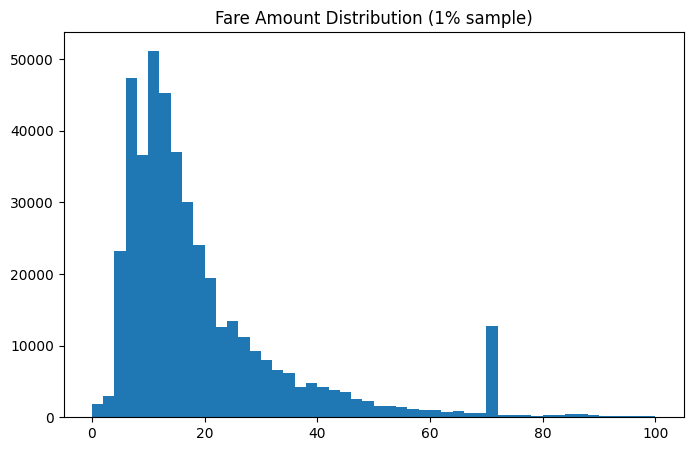

In [17]:
trip_type_df = clean.withColumn(
    "trip_type", F.when(F.col("RatecodeID").isin([2, 3]), "Airport").otherwise("Standard")
)

fare_economics = trip_type_df.groupBy("trip_type").agg(
    F.avg("fare_amount").alias("avg_fare"),
    F.avg("total_amount").alias("avg_total"),
    F.avg("trip_distance").alias("avg_distance"),
    F.avg("trip_minutes").alias("avg_duration"),
    F.count("*").alias("trip_count")
)
fare_economics.show(truncate=False)

sample_fares = clean.select("fare_amount").sample(fraction=0.01, seed=42).toPandas()
plt.figure(figsize=(8,5))
plt.hist(sample_fares["fare_amount"], bins=50, range=(0, 100))
plt.title("Fare Amount Distribution (1% sample)")
plt.show()

analysis_logs.append(("Step 3", "Compared airport vs standard trip economics and examined fare distribution."))

**Step 13: Tip Rate by Hour (Evaluating a Late-Night Tipping Premium)**

This step filters the dataset to include only card-payment transactions (payment_type=1), as cash transactions do not have tip amounts recorded due to a known TLC data limitation. The average tip percentage is then calculated per hour and visualized as a line chart, with late-night hours (10 PM–5 AM) highlighted.

Business insight: This analysis determines whether passengers tend to tip more generously during late-night hours, which could inform driver shift-scheduling decisions.

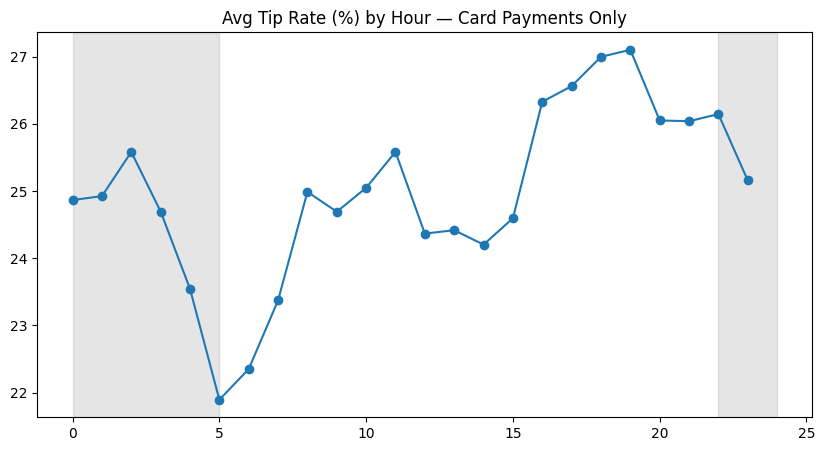

In [18]:
tip_rate_df = (
    clean.filter((F.col("payment_type") == 1) & (F.col("fare_amount") > 0))
    .withColumn("tip_rate_pct", (F.col("tip_amount") / F.col("fare_amount")) * 100)
)

tip_by_hour = tip_rate_df.groupBy("pickup_hour").agg(
    F.avg("tip_rate_pct").alias("avg_tip_rate_pct"),
    F.count("*").alias("trips")
).orderBy("pickup_hour")

pdf_tip = tip_by_hour.toPandas()
plt.figure(figsize=(10,5))
plt.plot(pdf_tip["pickup_hour"], pdf_tip["avg_tip_rate_pct"], marker="o")
plt.axvspan(0, 5, color="gray", alpha=0.2)
plt.axvspan(22, 24, color="gray", alpha=0.2)
plt.title("Avg Tip Rate (%) by Hour — Card Payments Only")
plt.show()

analysis_logs.append(("Step 4", "Analyzed tip rate by hour on card-paid trips to check for a late-night tipping premium."))

**Step 14: CBD Congestion Fee Impact**

This step classifies trips as either "CBD Trip" (where the congestion fee applied) or "Non-CBD Trip," then compares monthly trip volumes between the two categories.

Business insight: This analysis illustrates the level of activity within the CBD (Manhattan's congestion-priced zone) throughout the year, which is relevant to regulatory and pricing considerations. It should be noted that since the entire 2025 dataset postdates the implementation of the CBD fee, a direct before-and-after comparison is not possible; only the CBD versus non-CBD distribution can be examined.


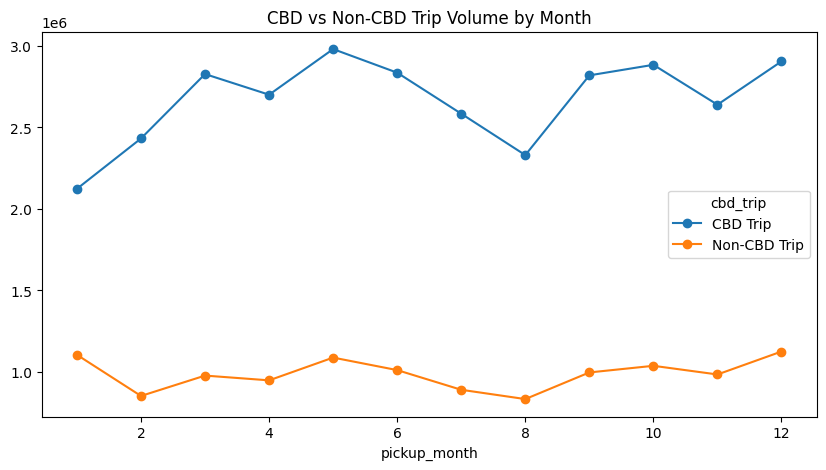

In [19]:
cbd_df = clean.withColumn(
    "cbd_trip", F.when(F.col("cbd_congestion_fee") > 0, "CBD Trip").otherwise("Non-CBD Trip")
)

cbd_monthly = cbd_df.groupBy("pickup_month", "cbd_trip").count().orderBy("pickup_month")
pdf_cbd = cbd_monthly.toPandas().pivot(index="pickup_month", columns="cbd_trip", values="count")
pdf_cbd.plot(kind="line", marker="o", figsize=(10,5))
plt.title("CBD vs Non-CBD Trip Volume by Month")
plt.show()

analysis_logs.append(("Step 5", "Examined CBD congestion-fee trips across months to identify usage patterns."))

**Step 15: Driver Revenue Optimization Model (KMeans Clustering)**

This step calculates average revenue, trip volume, and average tip for each combination of day of week and pickup hour, then trains a KMeans clustering model to group these time slots into three clusters representing high-, medium-, and low-earning shifts.

Rationale for using a machine learning model: Unlike the preceding exploratory analyses, this step produces an actionable model capable of directly identifying which days and hours constitute the most profitable shifts for drivers, extending the analysis beyond descriptive exploration.
Business insight: Examination of the cluster centers allows identification of the cluster associated with the highest revenue-per-trip and trip volume, which forms the basis for shift recommendations.

In [20]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans

shift_features = clean.groupBy("day_of_week", "pickup_hour").agg(
    F.avg("total_amount").alias("avg_revenue_per_trip"),
    F.count("*").alias("trip_volume"),
    F.avg("tip_amount").alias("avg_tip")
)

assembler = VectorAssembler(
    inputCols=["avg_revenue_per_trip", "trip_volume", "avg_tip"],
    outputCol="features"
)
feature_df = assembler.transform(shift_features)

kmeans = KMeans(k=3, seed=42, featuresCol="features", predictionCol="shift_cluster")
model = kmeans.fit(feature_df)
clustered = model.transform(feature_df)

clustered.orderBy(F.desc("avg_revenue_per_trip")).show(20, truncate=False)

analysis_logs.append(("Step 6", "Built a KMeans clustering model on (day, hour) shifts to identify best-earning shifts."))

+-----------+-----------+--------------------+-----------+------------------+-----------------------------------------------+-------------+
|day_of_week|pickup_hour|avg_revenue_per_trip|trip_volume|avg_tip           |features                                       |shift_cluster|
+-----------+-----------+--------------------+-----------+------------------+-----------------------------------------------+-------------+
|2          |4          |36.590721536834714  |28370      |2.6202534367289396|[36.590721536834714,28370.0,2.6202534367289396]|1            |
|2          |0          |36.433028532740224  |103390     |3.448781893800177 |[36.433028532740224,103390.0,3.448781893800177]|1            |
|2          |5          |35.827701007001856  |50844      |2.703036936511684 |[35.827701007001856,50844.0,2.703036936511684] |1            |
|3          |4          |35.70033581894978   |19177      |2.6067596600093865|[35.70033581894978,19177.0,2.6067596600093865] |1            |
|6          |5      

**Step 16: Saving Analysis Logs to Google Drive**

This step first saves a summary of all analytical steps (analysis_logs) to local disk as a CSV file, then copies it to a designated folder within the user's own Google Drive, where full write access is available.

Rationale for the local-then-Drive approach: Spark's direct write operations do not function reliably on Google Drive due to its FUSE-mounted architecture. Writing to local storage (/content/) first, followed by copying to Drive, circumvents this limitation. This step ensures documentation and traceability, allowing an instructor or reviewer to review the complete analytical process through a single consolidated log file.

In [23]:
import shutil, os

drive_log_path = "/content/drive/MyDrive/NYC_Taxi_Analysis_Logs"

if os.path.exists(drive_log_path):
    shutil.rmtree(drive_log_path)

shutil.copytree(local_log_path, drive_log_path)

print("Analysis logs saved to Drive at:", drive_log_path)

Analysis logs saved to Drive at: /content/drive/MyDrive/NYC_Taxi_Analysis_Logs
